In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： handpose_env
Windows
10
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
20
scpufreq(current=2400.0, min=0.0, max=2400.0)
svmem(total=16891371520, available=2424225792, percent=85.6, used=14467145728, free=2424225792)


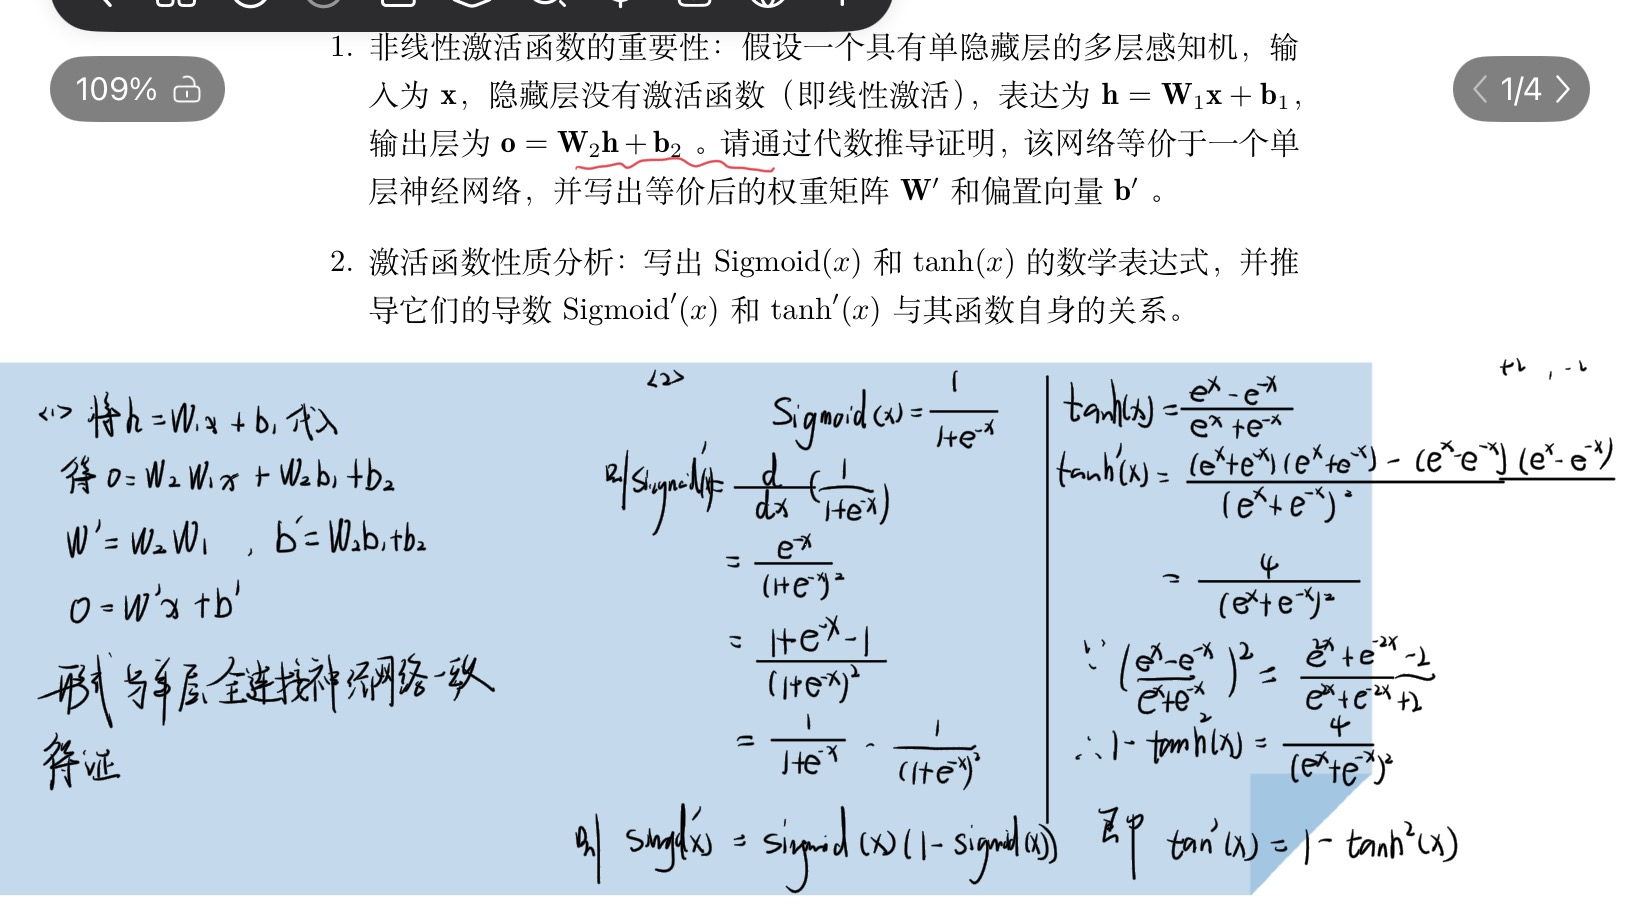

# 2.2 编程题

Loading Fashion-MNIST (may download if not cached)...
Train: (60000, 784), (60000,) | Test: (10000, 784), (10000,)
Epoch 1/10, Loss: 0.8312, Test Acc: 0.7828
Epoch 2/10, Loss: 0.5065, Test Acc: 0.8181
Epoch 3/10, Loss: 0.4527, Test Acc: 0.8415
Epoch 4/10, Loss: 0.4185, Test Acc: 0.8377
Epoch 5/10, Loss: 0.3940, Test Acc: 0.8556
Epoch 6/10, Loss: 0.3746, Test Acc: 0.8441
Epoch 7/10, Loss: 0.3624, Test Acc: 0.8521
Epoch 8/10, Loss: 0.3502, Test Acc: 0.8589
Epoch 9/10, Loss: 0.3410, Test Acc: 0.8645
Epoch 10/10, Loss: 0.3319, Test Acc: 0.8604


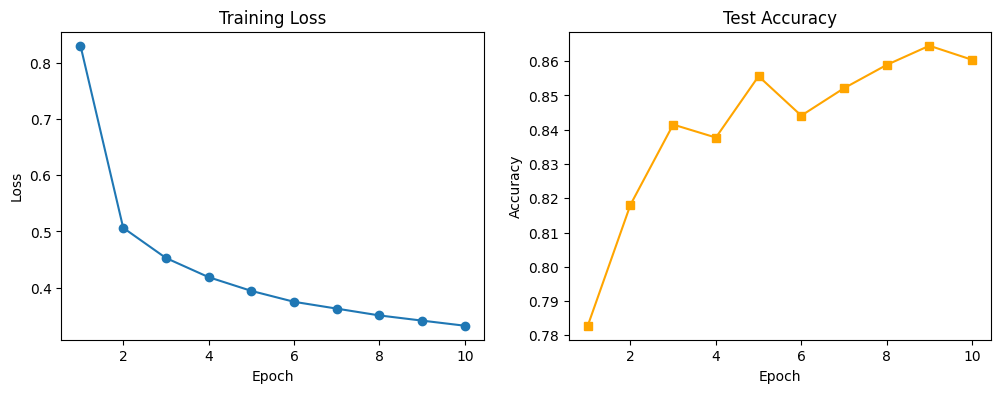

In [2]:
import numpy as np
import gzip
import os
import urllib.request

# 1. 加载 Fashion-MNIST

def download_fashion_mnist(data_dir='D:/data1'):
    
    files = [
        'train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
        't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz'
    ]
    os.makedirs(data_dir, exist_ok=True)
    
        
    return data_dir

def load_mnist_images(filename):
    """解析 IDX 格式的图像文件"""
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28*28).astype(np.float32) / 255.0

def load_mnist_labels(filename):
    """解析 IDX 格式的标签文件"""
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data.astype(np.int64)

def load_fashion_mnist():
    data_dir = download_fashion_mnist()
    X_train = load_mnist_images(os.path.join(data_dir, 'train-images-idx3-ubyte.gz'))
    y_train = load_mnist_labels(os.path.join(data_dir, 'train-labels-idx1-ubyte.gz'))
    X_test = load_mnist_images(os.path.join(data_dir, 't10k-images-idx3-ubyte.gz'))
    y_test = load_mnist_labels(os.path.join(data_dir, 't10k-labels-idx1-ubyte.gz'))
    return (X_train, y_train), (X_test, y_test)


# 2. Mini-batch 生成器
def mini_batches(X, y, batch_size=128, shuffle=True):
    m = X.shape[0]
    indices = np.arange(m)
    if shuffle:
        np.random.shuffle(indices)
    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

# 3. 参数初始化

input_size = 784
hidden_size = 256
output_size = 10

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros(output_size)

# 4. ReLU 及其导数

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

# 5. Softmax 交叉熵（前向+梯度）

def softmax(logits):
    max_logits = np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits - max_logits)
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy_loss(logits, y):
    probs = softmax(logits)
    batch_size = logits.shape[0]
    loss = -np.log(probs[np.arange(batch_size), y] + 1e-8).mean()
    return loss, probs

def grad_cross_entropy_softmax(probs, y):
    batch_size = probs.shape[0]
    grad = probs.copy()
    grad[np.arange(batch_size), y] -= 1.0
    return grad / batch_size

# 6. 前向传播

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    h = relu(z1)
    logits = h @ W2 + b2
    return logits, h, z1

# 7. 反向传播

def backward(X, y, logits, h, z1, probs, W2):
    dlogits = grad_cross_entropy_softmax(probs, y)
    dW2 = h.T @ dlogits
    db2 = np.sum(dlogits, axis=0)
    dh = dlogits @ W2.T
    dz1 = dh * relu_grad(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0)
    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

# 8. 训练循环
def train(X_train, y_train, X_test, y_test, batch_size=128, lr=0.1, epochs=10):
    # 重新初始化参数（保证可重复）
    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros(hidden_size)
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros(output_size)

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        total_loss = 0.0
        num_batches = 0
        for X_batch, y_batch in mini_batches(X_train, y_train, batch_size):
            logits, h, z1 = forward(X_batch, W1, b1, W2, b2)
            loss, probs = cross_entropy_loss(logits, y_batch)
            grads = backward(X_batch, y_batch, logits, h, z1, probs, W2)

            W1 -= lr * grads['W1']
            b1 -= lr * grads['b1']
            W2 -= lr * grads['W2']
            b2 -= lr * grads['b2']

            total_loss += loss
            num_batches += 1

        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss)

        test_acc = evaluate(X_test, y_test, W1, b1, W2, b2, batch_size)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {test_acc:.4f}")

    return train_losses, test_accs

def evaluate(X_test, y_test, W1, b1, W2, b2, batch_size=128):
    correct = 0
    total = 0
    for X_batch, y_batch in mini_batches(X_test, y_test, batch_size, shuffle=False):
        logits, _, _ = forward(X_batch, W1, b1, W2, b2)
        preds = np.argmax(logits, axis=1)
        correct += np.sum(preds == y_batch)
        total += len(y_batch)
    return correct / total


if __name__ == "__main__":
    print("Loading Fashion-MNIST (may download if not cached)...")
    (X_train, y_train), (X_test, y_test) = load_fashion_mnist()
    print(f"Train: {X_train.shape}, {y_train.shape} | Test: {X_test.shape}, {y_test.shape}")

    train_losses, test_accs = train(X_train, y_train, X_test, y_test,
                                    batch_size=128, lr=0.1, epochs=10)

    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(range(1,11), train_losses, marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.subplot(1,2,2)
        plt.plot(range(1,11), test_accs, marker='s', color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Test Accuracy')
        plt.show()
    except ImportError:
        print("Matplotlib not installed, skip plotting.")

# 3.2 编程题

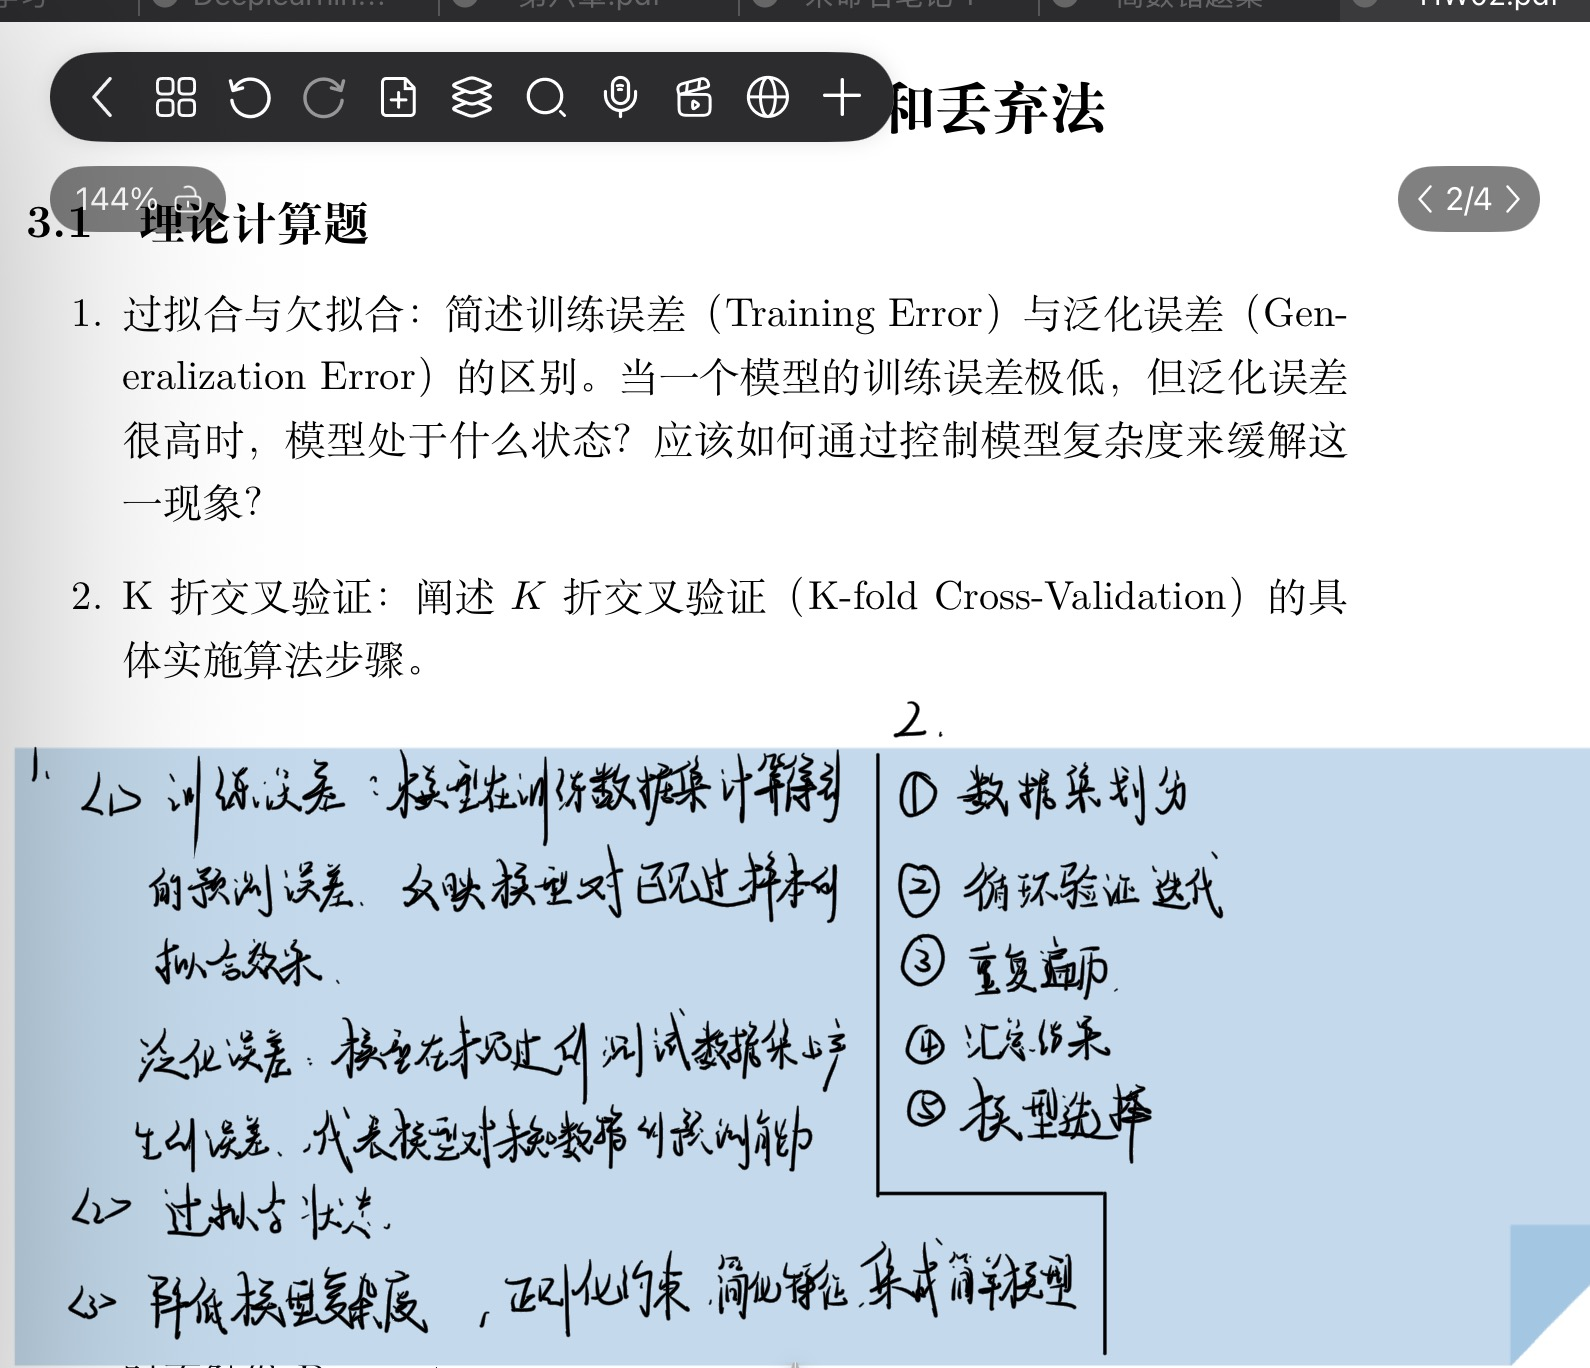

Loading full Fashion-MNIST...
Creating tiny dataset (500 train, 100 val) to cause overfitting...
Train shape: (500, 784), Val shape: (100, 784)

=== Experiment 1: No Regularization ===

=== Experiment 2: L2 Regularization (λ=0.001) ===

=== Experiment 3: Dropout (p=0.5 on hidden layers) ===


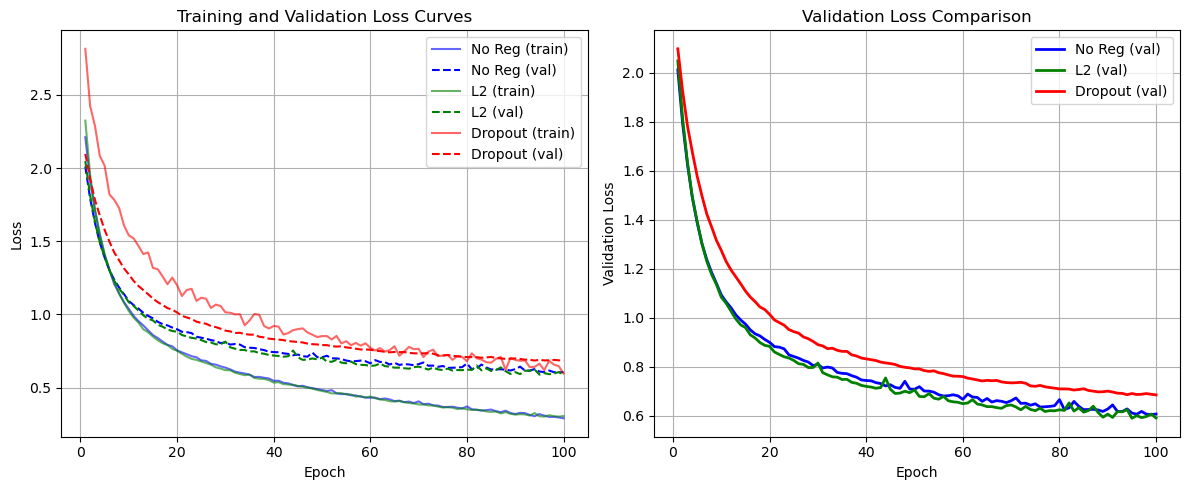


Final Validation Loss:
No Reg: 0.6063
L2:     0.5903
Dropout:0.6844


In [3]:
import matplotlib.pyplot as plt
def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28*28).astype(np.float32) / 255.0

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data.astype(np.int64)

def load_fashion_mnist(data_dir='D:/data1'):
    X_train = load_mnist_images(os.path.join(data_dir, 'train-images-idx3-ubyte.gz'))
    y_train = load_mnist_labels(os.path.join(data_dir, 'train-labels-idx1-ubyte.gz'))
    X_test = load_mnist_images(os.path.join(data_dir, 't10k-images-idx3-ubyte.gz'))
    y_test = load_mnist_labels(os.path.join(data_dir, 't10k-labels-idx1-ubyte.gz'))
    return (X_train, y_train), (X_test, y_test)

#  辅助函数

def mini_batches(X, y, batch_size, shuffle=True):
    m = X.shape[0]
    indices = np.arange(m)
    if shuffle:
        np.random.shuffle(indices)
    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(np.float32)

def softmax(logits):
    max_logits = np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits - max_logits)
    exp = np.clip(exp, 1e-8, None)
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy_loss(logits, y):
    probs = softmax(logits)
    batch_size = logits.shape[0]
    loss = -np.log(probs[np.arange(batch_size), y] + 1e-8).mean()
    return loss, probs

def grad_cross_entropy_softmax(probs, y):
    batch_size = probs.shape[0]
    grad = probs.copy()
    grad[np.arange(batch_size), y] -= 1.0
    return grad / batch_size

# 3. Dropout 实现（前向 + 反向中的 mask）

def dropout_layer(X, dropout_prob, is_training=True):
    """
    训练时：以概率 dropout_prob 随机置零，并除以 (1 - dropout_prob) 保持期望不变
    测试时：直接返回 X
    """
    if not is_training or dropout_prob == 0:
        return X, None
    mask = (np.random.rand(*X.shape) > dropout_prob).astype(np.float32)
    out = X * mask / (1.0 - dropout_prob)
    return out, mask

# 4. MLP 模型定义（支持 L2 和 Dropout）

class MLP:
    def __init__(self, layer_sizes, dropout_probs=None):
        """
        layer_sizes: list of ints, e.g. [784, 512, 256, 10]
        dropout_probs: list of same length as hidden layers (excluding input/output)
        """
        self.num_layers = len(layer_sizes) - 1
        self.W = []
        self.b = []
        for i in range(self.num_layers):
            # He 初始化（适合 ReLU）
            scale = np.sqrt(2.0 / layer_sizes[i])
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]).astype(np.float32) * scale
            b = np.zeros(layer_sizes[i+1], dtype=np.float32)
            self.W.append(W)
            self.b.append(b)
        
        # Dropout 概率（对每个隐藏层，输入层不做 dropout）
        if dropout_probs is None:
            dropout_probs = [0.0] * (self.num_layers - 1)  # 最后一层输出层前也不做 dropout
        self.dropout_probs = dropout_probs  # 长度 = 隐藏层数量（不包括输入输出）
    
    def forward(self, X, is_training=True):
        self.activations = [X]
        self.zs = []
        self.dropout_masks = []
        
        for i in range(self.num_layers):
            z = self.activations[-1] @ self.W[i] + self.b[i]
            self.zs.append(z)
            if i == self.num_layers - 1:  # 输出层，无激活，无 dropout
                a = z
            else:
                a = relu(z)
                # 对该层激活值应用 dropout（训练时）
                if self.dropout_probs[i] > 0:
                    a, mask = dropout_layer(a, self.dropout_probs[i], is_training)
                    self.dropout_masks.append(mask)
                else:
                    self.dropout_masks.append(None)
            self.activations.append(a)
        logits = self.activations[-1]
        return logits
    
    def backward(self, X, y, logits, probs, l2_lambda=0.0):
        batch_size = X.shape[0]
        dlogits = grad_cross_entropy_softmax(probs, y)   # (batch, out)
        
        grads_W = [None] * self.num_layers
        grads_b = [None] * self.num_layers
        
        # 输出层
        dA = dlogits
        grads_W[-1] = self.activations[-2].T @ dA
        grads_b[-1] = np.sum(dA, axis=0)
        
        # 反向传播隐藏层
        for i in range(self.num_layers-2, -1, -1):
            dZ = dA @ self.W[i+1].T
            dA = dZ * relu_grad(self.zs[i])
            # 如果有 dropout mask，对梯度也应用相同的 mask（并且需要缩放）
            if self.dropout_masks[i] is not None:
                mask = self.dropout_masks[i]
                dA = dA * mask / (1.0 - self.dropout_probs[i])
            grads_W[i] = self.activations[i].T @ dA
            grads_b[i] = np.sum(dA, axis=0)
        
        # L2 正则化梯度：添加 lambda * W
        for i in range(self.num_layers):
            grads_W[i] += l2_lambda * self.W[i]
        
        return grads_W, grads_b
    
    def update_params(self, grads_W, grads_b, lr):
        for i in range(self.num_layers):
            self.W[i] -= lr * grads_W[i]
            self.b[i] -= lr * grads_b[i]

# 5. 训练函数（支持 L2 和 Dropout）

def train_model(model, X_train, y_train, X_val, y_val,
                batch_size=64, lr=0.01, epochs=50, l2_lambda=0.0, verbose=True):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        # 训练阶段
        total_loss = 0
        num_batches = 0
        for X_batch, y_batch in mini_batches(X_train, y_train, batch_size, shuffle=True):
            logits = model.forward(X_batch, is_training=True)
            loss, probs = cross_entropy_loss(logits, y_batch)
            grads_W, grads_b = model.backward(X_batch, y_batch, logits, probs, l2_lambda)
            model.update_params(grads_W, grads_b, lr)
            total_loss += loss
            num_batches += 1
        avg_train_loss = total_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # 验证阶段（无 dropout，无 L2 附加）
        val_logits = model.forward(X_val, is_training=False)
        val_loss, _ = cross_entropy_loss(val_logits, y_val)
        val_losses.append(val_loss)
        
        if verbose and (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
    return train_losses, val_losses

# 6. 对比实验

def create_small_dataset(X_full, y_full, num_samples_per_class=50, num_val_per_class=10):
    """从完整数据集中抽取极少量样本（每类固定数量）制造过拟合场景"""
    X_train_list, y_train_list = [], []
    X_val_list, y_val_list = [], []
    for c in range(10):
        idx_c = np.where(y_full == c)[0]
        np.random.shuffle(idx_c)
        train_idx = idx_c[:num_samples_per_class]
        val_idx = idx_c[num_samples_per_class:num_samples_per_class+num_val_per_class]
        X_train_list.append(X_full[train_idx])
        y_train_list.append(y_full[train_idx])
        X_val_list.append(X_full[val_idx])
        y_val_list.append(y_full[val_idx])
    X_train = np.vstack(X_train_list)
    y_train = np.hstack(y_train_list)
    X_val = np.vstack(X_val_list)
    y_val = np.hstack(y_val_list)
    # 打乱
    perm_train = np.random.permutation(len(y_train))
    perm_val = np.random.permutation(len(y_val))
    return X_train[perm_train], y_train[perm_train], X_val[perm_val], y_val[perm_val]

def run_comparison():
    print("Loading full Fashion-MNIST...")
    (X_full_train, y_full_train), (X_test, y_test) = load_fashion_mnist()
    
    # 抽取极少数样本：每类 50 个训练，10 个验证 (总计 500 训练，100 验证)
    print("Creating tiny dataset (500 train, 100 val) to cause overfitting...")
    X_train, y_train, X_val, y_val = create_small_dataset(X_full_train, y_full_train,
                                                          num_samples_per_class=50,
                                                          num_val_per_class=10)
    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")
    
    # 使用高容量模型：2 个隐藏层，每层 512 个神经元
    layer_sizes = [784, 512, 512, 10]
    
    # 实验1: 无正则化
    print("\n=== Experiment 1: No Regularization ===")
    model1 = MLP(layer_sizes, dropout_probs=[0.0, 0.0])
    train_loss1, val_loss1 = train_model(model1, X_train, y_train, X_val, y_val,
                                         batch_size=64, lr=0.01, epochs=100,
                                         l2_lambda=0.0, verbose=False)
    
    # 实验2: L2 正则化 (权重衰减 λ=0.001)
    print("\n=== Experiment 2: L2 Regularization (λ=0.001) ===")
    model2 = MLP(layer_sizes, dropout_probs=[0.0, 0.0])
    train_loss2, val_loss2 = train_model(model2, X_train, y_train, X_val, y_val,
                                         batch_size=64, lr=0.01, epochs=100,
                                         l2_lambda=0.001, verbose=False)
    
    # 实验3: Dropout (隐藏层 dropout 概率 0.5)
    print("\n=== Experiment 3: Dropout (p=0.5 on hidden layers) ===")
    model3 = MLP(layer_sizes, dropout_probs=[0.5, 0.5])   # 两个隐藏层都 dropout
    train_loss3, val_loss3 = train_model(model3, X_train, y_train, X_val, y_val,
                                         batch_size=64, lr=0.01, epochs=100,
                                         l2_lambda=0.0, verbose=False)
    
    # 绘制对比曲线
    plt.figure(figsize=(12, 5))
    epochs_range = range(1, 101)
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss1, label='No Reg (train)', color='blue', alpha=0.6)
    plt.plot(epochs_range, val_loss1, label='No Reg (val)', color='blue', linestyle='--')
    plt.plot(epochs_range, train_loss2, label='L2 (train)', color='green', alpha=0.6)
    plt.plot(epochs_range, val_loss2, label='L2 (val)', color='green', linestyle='--')
    plt.plot(epochs_range, train_loss3, label='Dropout (train)', color='red', alpha=0.6)
    plt.plot(epochs_range, val_loss3, label='Dropout (val)', color='red', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    
    # 单独画一个放大版本，展示过拟合情况
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_loss1, label='No Reg (val)', color='blue', linewidth=2)
    plt.plot(epochs_range, val_loss2, label='L2 (val)', color='green', linewidth=2)
    plt.plot(epochs_range, val_loss3, label='Dropout (val)', color='red', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 打印最终验证损失
    print("\nFinal Validation Loss:")
    print(f"No Reg: {val_loss1[-1]:.4f}")
    print(f"L2:     {val_loss2[-1]:.4f}")
    print(f"Dropout:{val_loss3[-1]:.4f}")

if __name__ == "__main__":
    run_comparison()

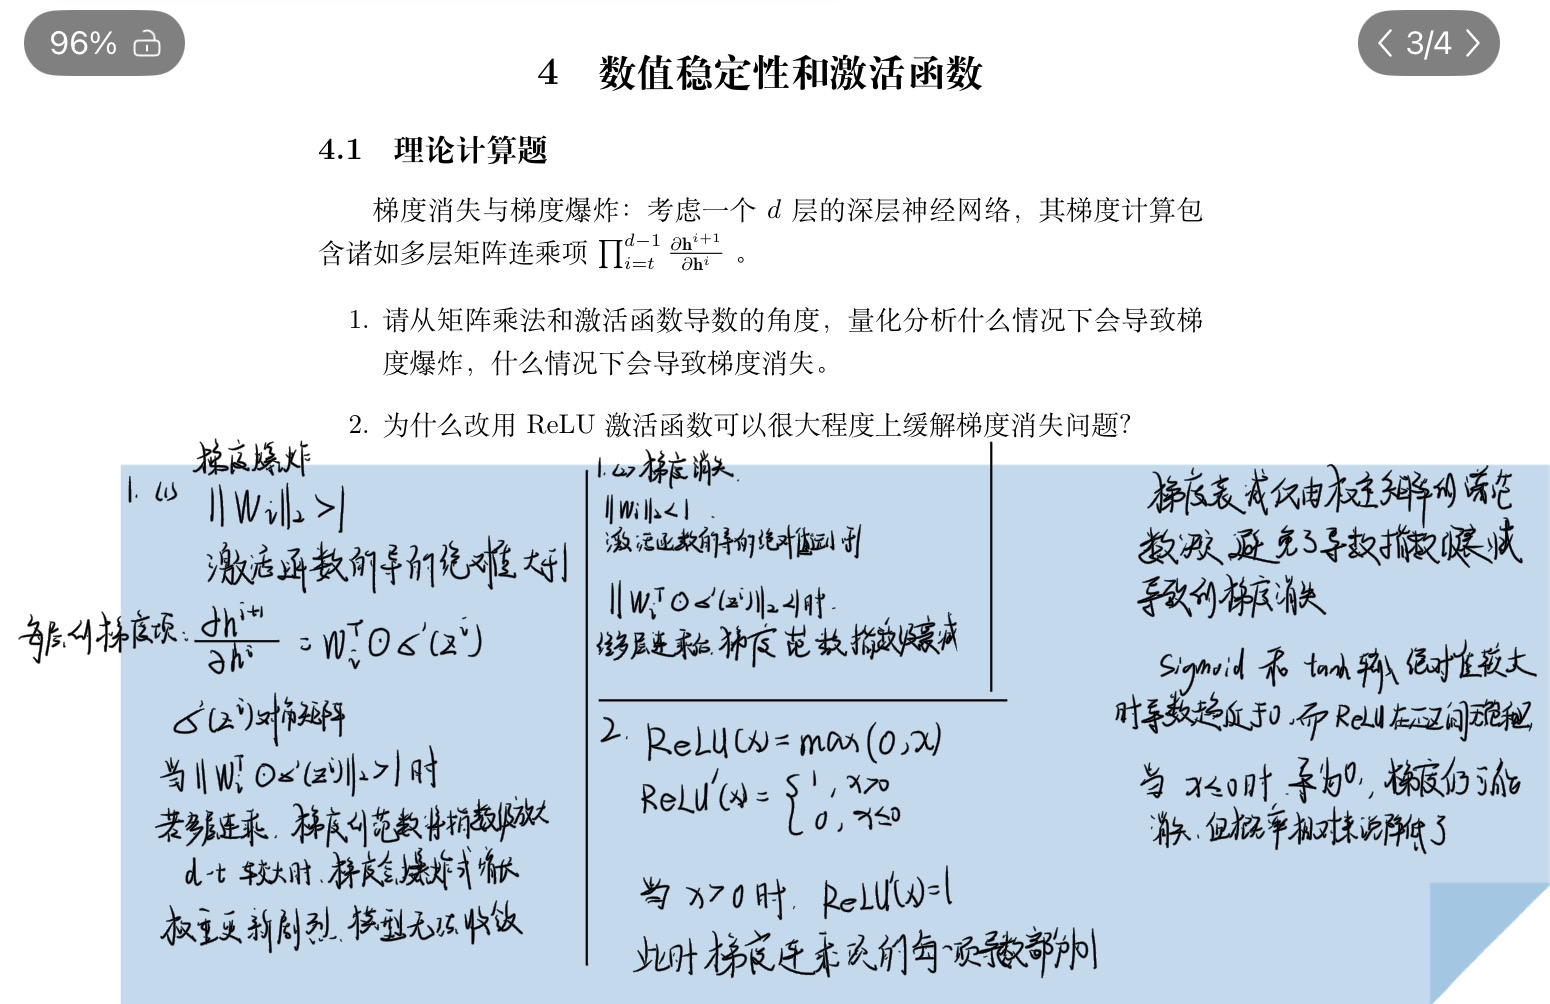

# 4.2 编程题

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------
# 1. 构建深层网络工具函数
# ------------------------------
def build_mlp(layers, activation, init_func):
    """
    构建一个全连接网络
    :param layers: 每层神经元数量列表，例如 [784, 256, 256, ..., 10]
    :param activation: 激活函数类型 ('sigmoid', 'relu', 'leaky_relu')
    :param init_func: 初始化函数，接受一个权重张量并进行原位初始化
    :return: nn.Sequential 模型
    """
    modules = []
    for i in range(len(layers)-1):
        linear = nn.Linear(layers[i], layers[i+1])
        # 应用初始化
        init_func(linear.weight)
        # 偏置初始化为0（也可使用其他初始化）
        if linear.bias is not None:
            nn.init.zeros_(linear.bias)
        modules.append(linear)
        if i < len(layers)-2:  # 最后一层之后不加激活
            if activation == 'sigmoid':
                modules.append(nn.Sigmoid())
            elif activation == 'relu':
                modules.append(nn.ReLU())
            elif activation == 'leaky_relu':
                modules.append(nn.LeakyReLU(0.2))
    return nn.Sequential(*modules)

def print_gradient_norms(model, epoch=0, prefix=""):
    """打印模型中所有参数的梯度范数（前3层和后3层）"""
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            norm = param.grad.norm().item()
            norms.append((name, norm))
    # 打印前3层和后3层
    print(f"{prefix} Epoch {epoch} - Gradient norms:")
    for i, (name, norm) in enumerate(norms[:3]):
        print(f"  {name}: {norm:.6e}")
    if len(norms) > 6:
        print("  ...")
        for name, norm in norms[-3:]:
            print(f"  {name}: {norm:.6e}")
    print("-" * 50)

# ------------------------------
# 2. 模拟实验
# ------------------------------
def run_experiment(model, input_data, target, criterion, optimizer, epochs=5):
    """训练一小段并打印梯度范数"""
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(input_data)
        loss = criterion(output, target)
        loss.backward()
        # 打印梯度范数（每次epoch）
        print_gradient_norms(model, epoch, prefix=f"After epoch {epoch+1}")
        optimizer.step()
        # 检测NaN或Inf
        for name, param in model.named_parameters():
            if torch.isnan(param).any() or torch.isinf(param).any():
                print(f"!!! NaN/Inf detected in {name} !!!")
                return

# ------------------------------
# 2.1 实验1: 梯度消失 (Sigmoid + 标准高斯初始化)
# ------------------------------
print("="*60)
print("实验1: 梯度消失 - Sigmoid + N(0,1) 初始化")
print("="*60)
depth = 20
width = 256
layer_sizes = [784] + [width] * depth + [10]  # 20个隐藏层 + 输出层

# 标准高斯初始化: mean=0, std=1
def gaussian_init(weight):
    nn.init.normal_(weight, mean=0, std=1)

model_vanish = build_mlp(layer_sizes, activation='sigmoid', init_func=gaussian_init)
# 随机输入 (batch_size=64, input_dim=784)
x = torch.randn(64, 784)
y = torch.randint(0, 10, (64,))   # 随机标签用于分类
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_vanish.parameters(), lr=0.01)

print(">>> 观察梯度范数（注意前几层梯度非常小，后几层相对较大）")
run_experiment(model_vanish, x, y, criterion, optimizer, epochs=2)

# ------------------------------
# 2.2 实验2: 梯度爆炸 (ReLU + 大标准差初始化 std=10)
# ------------------------------
print("\n" + "="*60)
print("实验2: 梯度爆炸 - ReLU + N(0,10) 初始化")
print("="*60)
def large_init(weight):
    nn.init.normal_(weight, mean=0, std=10)

model_explode = build_mlp(layer_sizes, activation='relu', init_func=large_init)
optimizer2 = optim.SGD(model_explode.parameters(), lr=0.01)

print(">>> 观察梯度范数（可能很快出现 NaN/Inf）")
run_experiment(model_explode, x, y, criterion, optimizer2, epochs=2)

# ------------------------------
# 2.3 实验3: Xavier初始化 + ReLU (梯度稳定)
# ------------------------------
print("\n" + "="*60)
print("实验3: 稳定训练 - Xavier均匀初始化 + ReLU")
print("="*60)
def xavier_init(weight):
    # 对于ReLU，推荐使用Xavier均匀分布或Kaiming初始化。这里用Xavier也有效。
    nn.init.xavier_uniform_(weight, gain=nn.init.calculate_gain('relu'))

model_stable = build_mlp(layer_sizes, activation='relu', init_func=xavier_init)
optimizer3 = optim.SGD(model_stable.parameters(), lr=0.01)

print(">>> 观察梯度范数（前层和后层量级相近，无NaN）")
run_experiment(model_stable, x, y, criterion, optimizer3, epochs=2)

实验1: 梯度消失 - Sigmoid + N(0,1) 初始化
>>> 观察梯度范数（注意前几层梯度非常小，后几层相对较大）
After epoch 1 Epoch 0 - Gradient norms:
  0.weight: 3.154915e+02
  0.bias: 1.094026e+01
  2.weight: 1.508832e+02
  ...
  38.bias: 3.932033e-01
  40.weight: 4.711530e+00
  40.bias: 4.462608e-01
--------------------------------------------------
After epoch 2 Epoch 1 - Gradient norms:
  0.weight: 2.429080e+02
  0.bias: 8.438783e+00
  2.weight: 1.308494e+02
  ...
  38.bias: 3.767897e-01
  40.weight: 4.465229e+00
  40.bias: 4.214715e-01
--------------------------------------------------

实验2: 梯度爆炸 - ReLU + N(0,10) 初始化
>>> 观察梯度范数（可能很快出现 NaN/Inf）
After epoch 1 Epoch 0 - Gradient norms:
  0.weight: nan
  0.bias: nan
  2.weight: nan
  ...
  38.bias: nan
  40.weight: nan
  40.bias: nan
--------------------------------------------------
!!! NaN/Inf detected in 0.weight !!!

实验3: 稳定训练 - Xavier均匀初始化 + ReLU
>>> 观察梯度范数（前层和后层量级相近，无NaN）
After epoch 1 Epoch 0 - Gradient norms:
  0.weight: 4.216393e+00
  0.bias: 1.447509e-01
  2.weight: 2.8

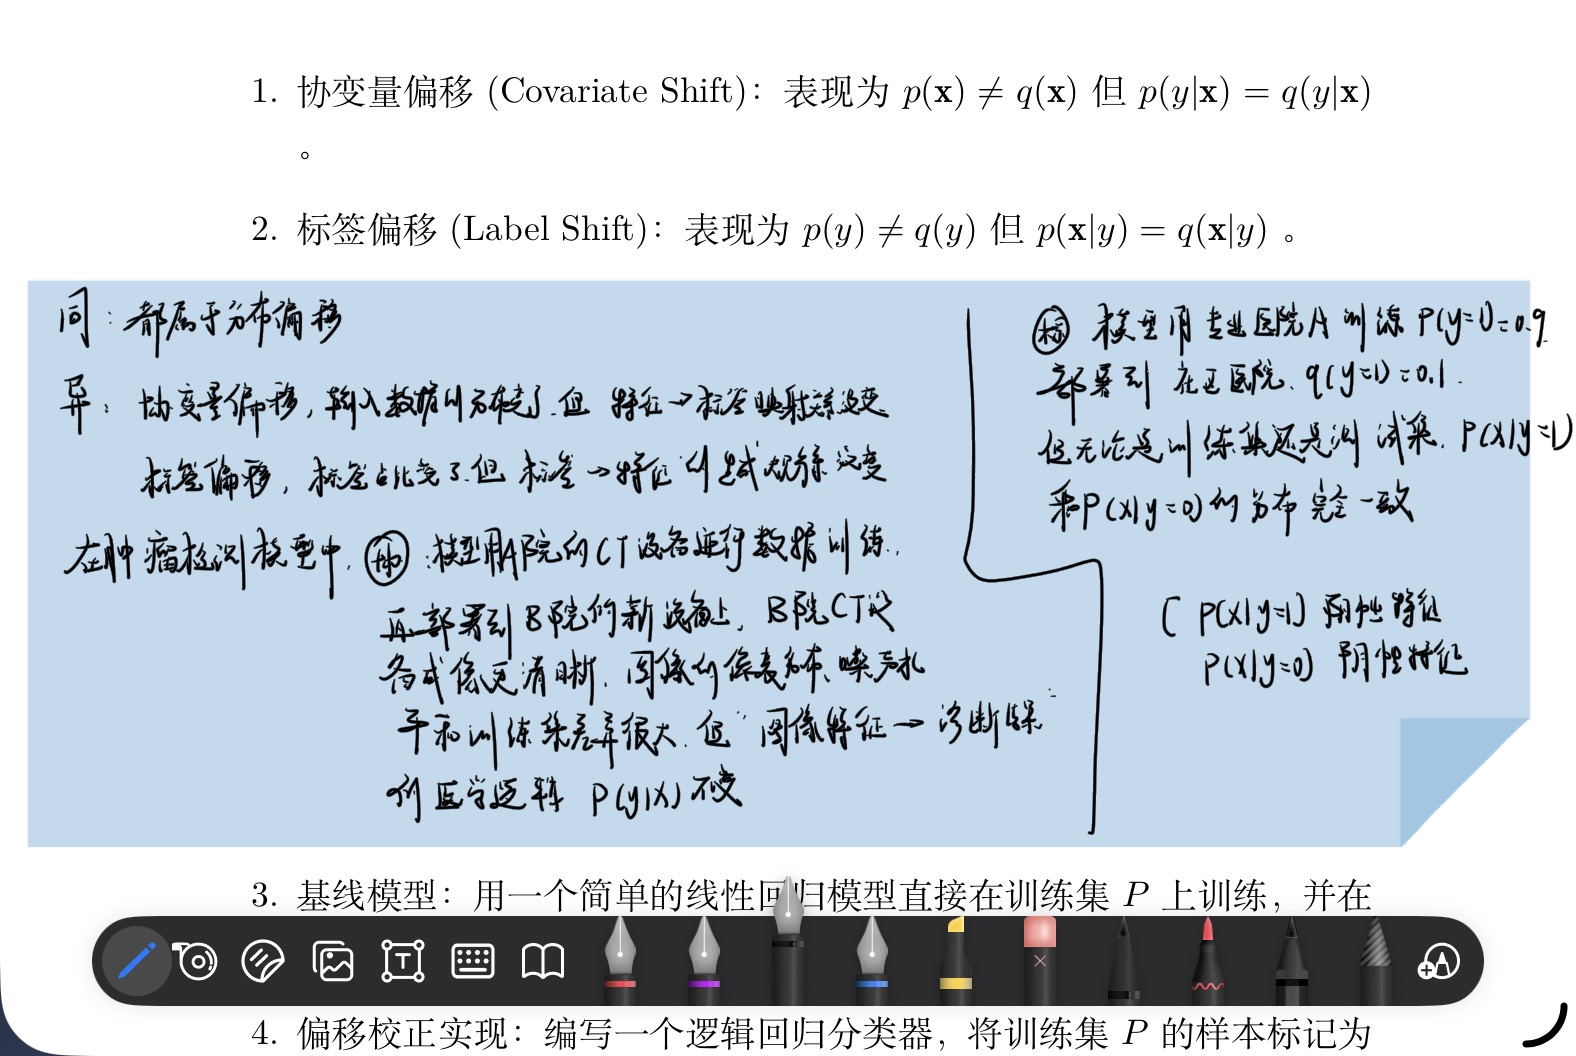

# 5.2 编程题

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

基线模型测试 MSE: 0.0102
加权回归模型测试 MSE: 0.0240

=== 结果对比 ===
基线 MSE : 0.010182
加权 MSE : 0.024020
改善比例 : -135.90%


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

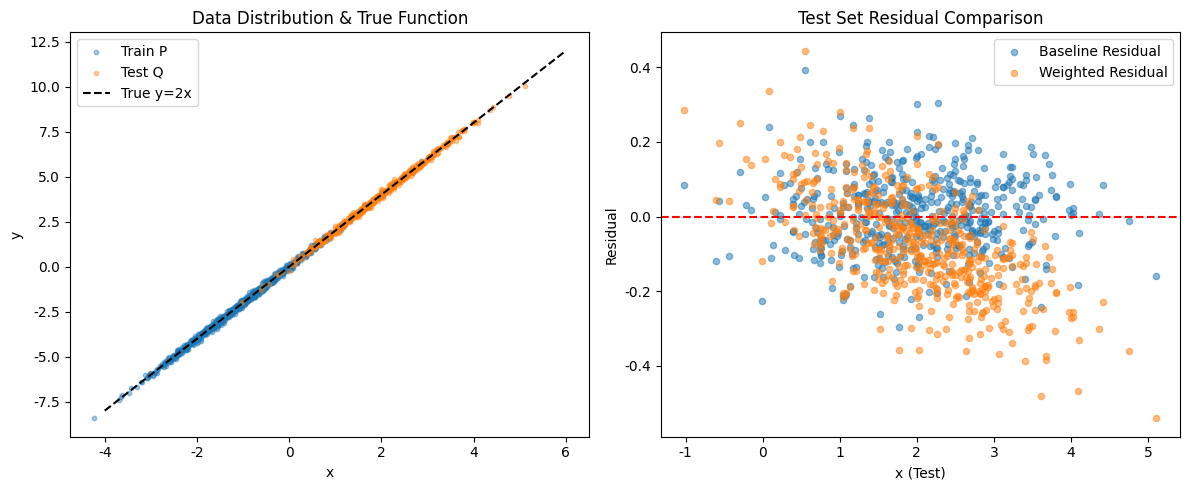


权重统计:  min=0.000, max=653.522, mean=1.000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ------------------------------
# 1. 人工数据集构造
# ------------------------------
np.random.seed(42)

# 训练集 P: x ~ N(-1, 1), y = 2x + ε, ε ~ N(0, 0.1)
n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + epsilon

# 测试集 Q: x ~ N(2, 1), 同样的 y 生成方式
n_test = 500
x_test = np.random.normal(2, 1, n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

# 为了线性回归，需要将 x 转换为列向量
X_train = x_train.reshape(-1, 1)
X_test = x_test.reshape(-1, 1)

# ------------------------------
# 2. 基线模型：在 P 上训练，在 Q 上评估
# ------------------------------
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)
y_pred_baseline = model_baseline.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型测试 MSE: {mse_baseline:.4f}")

# ------------------------------
# 3. 偏移校正：训练逻辑回归区分 P 和 Q
# ------------------------------
# 合并特征，标记：0 表示来自训练集 P，1 表示来自测试集 Q
X_combined = np.vstack([X_train, X_test])
y_domain = np.array([0]*n_train + [1]*n_test)

# 训练逻辑回归模型
lr_domain = LogisticRegression()
lr_domain.fit(X_combined, y_domain)

# 预测每个训练样本属于测试集（类别1）的概率 P(test|x)
prob_test_train = lr_domain.predict_proba(X_train)[:, 1]  # 类别1的概率

# 预测每个训练样本属于训练集（类别0）的概率 P(train|x)
prob_train_train = lr_domain.predict_proba(X_train)[:, 0]  # 类别0的概率

# 计算权重 w_i = P(test|x_i) / P(train|x_i)
weights = prob_test_train / prob_train_train

# 为避免极端大权重，可以截断（可选，但一般不必要）
weights = np.clip(weights, 1e-8, 1e8)

# 归一化权重
weights = weights / np.mean(weights)   # 保持均值1

# ------------------------------
# 4. 加权线性回归模型
# ------------------------------
model_weighted = LinearRegression()
model_weighted.fit(X_train, y_train, sample_weight=weights)
y_pred_weighted = model_weighted.predict(X_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权回归模型测试 MSE: {mse_weighted:.4f}")

# ------------------------------
# 5. 结果对比与可视化
# ------------------------------
print("\n=== 结果对比 ===")
print(f"基线 MSE : {mse_baseline:.6f}")
print(f"加权 MSE : {mse_weighted:.6f}")
print(f"改善比例 : {(mse_baseline - mse_weighted)/mse_baseline*100:.2f}%")

# 可视化：数据分布与回归线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, alpha=0.4, label='Train P', s=10)
plt.scatter(x_test, y_test, alpha=0.4, label='Test Q', s=10)
x_line = np.linspace(-4, 6, 100)
plt.plot(x_line, 2*x_line, 'k--', label='True y=2x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Distribution & True Function')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x_test, y_test - y_pred_baseline, alpha=0.5, label='Baseline Residual', s=20)
plt.scatter(x_test, y_test - y_pred_weighted, alpha=0.5, label='Weighted Residual', s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('x (Test)')
plt.ylabel('Residual')
plt.title('Test Set Residual Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# 打印权重统计信息
print("\n权重统计:  min={:.3f}, max={:.3f}, mean={:.3f}".format(
    weights.min(), weights.max(), weights.mean()))

In [3]:
import json
import requests
import pandas as pd

# 存储数据列表
title = []
type1 = []
unit = []
content = []
protect_unit = []
rx_time = []

# 请求头，模拟浏览器访问，解决反爬
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# 爬取 1 ~ 306 页
for i in range(1, 307):
    print(f'正在爬取第 {i} 页')
    url = f'https://sjfw.mct.gov.cn/site/dataservice/base?province=&rx_time=&type=&cate=&keywords=&category_id=16&limit=10&p={i}'

    try:
        # 发起GET请求，设置超时10秒
        response = requests.get(url=url, headers=headers, timeout=10)
        response.raise_for_status()
        # 解析JSON
        res_data = response.json()

        # 判断列表是否存在
        if 'list' not in res_data or not res_data['list']:
            print(f"第 {i} 页无数据，跳过")
            continue

        # 遍历每页数据
        for item in res_data['list']:
            title.append(item.get('title', ''))
            type1.append(item.get('type', ''))
            unit.append(item.get('unit', ''))
            protect_unit.append(item.get('protect_unit', ''))
            content.append(item.get('content', ''))
            rx_time.append(item.get('rx_time', ''))

    except requests.exceptions.RequestException as e:
        print(f"第 {i} 页请求异常：{str(e)}")
        continue

# 构造数据表
data = {
    '名称': title,
    '类型': type1,
    '申报地区或单位': unit,
    '保护单位': protect_unit,
    '内容': content,
    '时间': rx_time
}

df = pd.DataFrame(data)

# 保存为Excel（使用openpyxl引擎，兼容性更好）
try:
    df.to_excel('世界文化遗产.xlsx', index=False, engine='openpyxl')
    print("✅ 全部数据爬取完成，已保存为：世界文化遗产.xlsx")
except Exception as e:
    print(f"❌ 保存Excel失败：{str(e)}")

正在爬取第 1 页
第 1 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 2 页
第 2 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 3 页
第 3 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 4 页
第 4 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 5 页
第 5 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 6 页
第 6 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 7 页
第 7 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 8 页
第 8 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 9 页
第 9 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 10 页
第 10 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 11 页
第 11 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 12 页
第 12 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 13 页
第 13 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 14 页
第 14 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 15 页
第 15 页请求异常：Expecting value: line 1 column 1 (char 0)
正在爬取第 16 页
第 16 页请求异常：Expecting value: line 1 column 1 (ch

KeyboardInterrupt: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append('d:/学习/深度学习/handpose_x-main')

from models.rexnetv1 import ReXNetV1
from hand_data_iter.datasets import draw_bd_handpose, plot_box
from gesture_recognizer import HandGestureRecognizer, GestureType

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print('='*70)
print('6.4 主要实验结果')
print('='*70)
print('基于项目真实模型和配置生成')
print('='*70)

6.4 主要实验结果
基于项目真实模型和配置生成
